In [55]:
from pyrosm import OSM, get_data
import matplotlib.pyplot as plt
import seaborn as sns
import h3

In [56]:
# Connect to H3 Hexagons (Task 1 & 2 requirement) [cite: 48, 51]
# We'll use resolution 8 as a starting point for "discretizing the city"
def get_h3_index(row):
    # Get the centroid of the POI geometry
    centroid = row.geometry.centroid
    return h3.latlng_to_cell(centroid.y, centroid.x, 8)

In [57]:
fp = get_data("Chicago", directory="data")
osm = OSM(fp)

In [58]:
custom_filter = {'amenity': True, "shop": True, "tourism": True}
pois = osm.get_pois(custom_filter=custom_filter)
pois.head()

,changeset,lon,timestamp,version,lat,visible,tags,id,addr:city,addr:country,...,bank,bbq,police,games,golf,swimming_pool,trailer,vacuum_cleaner,water,zoo
0,159129735.0,-87.622520,1731589808,14,41.889145,False,"{""ferry"":""yes"",""network"":""Shoreline Water Taxi...",20217109,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,154868964.0,-87.637741,1722892561,12,41.879063,False,"{""addr:state"":""IL"",""ferry"":""yes"",""network"":""Sh...",20217442,Chicago,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,36433369.0,-87.990929,1452199796,8,42.028557,False,"{""addr:state"":""IL"",""fee"":""no"",""park_ride"":""no""...",261177673,Elk Grove Village,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,123936649.0,-87.928909,1658491802,5,42.034115,False,None,262376566,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,80328501.0,-87.615059,1580403706,5,41.858688,False,None,269449042,None,None,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [59]:
unique_amenities = pois['amenity'].unique()

print(f"Total unique amenities: {len(unique_amenities)}")
print(unique_amenities)

Total unique amenities: 158
['ferry_terminal' 'parking' None 'parking_entrance' 'post_box'
 'loading_dock' 'theatre' 'bicycle_parking' 'place_of_worship' 'fast_food'
 'post_office' 'drinking_water' 'toilets' 'restaurant' 'pharmacy' 'fuel'
 'cafe' 'cinema' 'clock' 'pub' 'school' 'university' 'grave_yard'
 'kindergarten' 'dojo' 'driving_school' 'childcare' 'college'
 'music_school' 'language_school' 'social_facility' 'prep_school'
 'public_bath' 'social_centre' 'arts_centre' 'courthouse' 'fire_station'
 'library' 'police' 'townhall' 'bar' 'bank' 'atm' 'ice_cream' 'car_wash'
 'veterinary' 'doctors' 'fountain' 'dentist' 'bench' 'waste_basket'
 'car_rental' 'community_centre' 'shelter' 'recycling' 'bicycle_rental'
 'clinic' 'bureau_de_change' 'studio' 'car_sharing' 'money_transfer' 'spa'
 'research_institute' 'ticket_validator' 'shower' 'charging_station'
 'parking_space' 'telephone' 'boat_rental' 'brewery' 'animal_shelter'
 'events_venue' 'salon' 'vending_machine' 'locker' 'marketplace'
 '

In [60]:
missing_amenity_df = pois[pois['amenity'].isna()]
print(f"Total rows with missing amenity: {len(missing_amenity_df)}")
cols_to_show = ['id', 'name', 'shop', 'tourism', 'geometry', 'h3_index']
existing_cols = [c for c in cols_to_show if c in pois.columns]
missing_amenity_df[existing_cols].head(20)

Total rows with missing amenity: 12504


,id,name,shop,tourism,geometry
3,262376566,None,None,picnic_site,POINT (-87.92891 42.03411)
8,269691663,Edgebrook Cycle,bicycle,None,POINT (-87.7634 41.99887)
12,282360641,Oak Park Visitors Center,None,information,POINT (-87.801 41.8888)
13,282370094,7-Eleven,convenience,None,POINT (-87.8373 41.97632)
15,286083842,Pep Boys,car_repair,None,POINT (-87.75834 42.01245)
22,286482248,Smithe Furniture,furniture,None,POINT (-87.7462 42.05585)
24,287160477,DePaul University Bookstore,books,None,POINT (-87.6534 41.92602)
26,287178413,None,dry_cleaning,None,POINT (-87.74919 42.02611)
30,294829415,Jewel-Osco,supermarket,None,POINT (-87.74471 42.05288)
35,306744421,Staples,stationery,None,POINT (-87.62591 41.88341)


In [62]:
pois["poi_type"] = pois["amenity"]
pois["poi_type"] = pois["poi_type"].fillna(pois["shop"]).fillna(pois["tourism"])

In [63]:
missing_poi_df = pois[pois['poi_type'].isna()]
print(f"Total rows with missing poi_type: {len(missing_poi_df)}")
cols_to_show = ['id', 'name', 'shop', 'tourism', 'geometry', 'h3_index']
existing_cols = [c for c in cols_to_show if c in pois.columns]
missing_poi_df[existing_cols].head(20)

Total rows with missing poi_type: 0


,id,name,shop,tourism,geometry


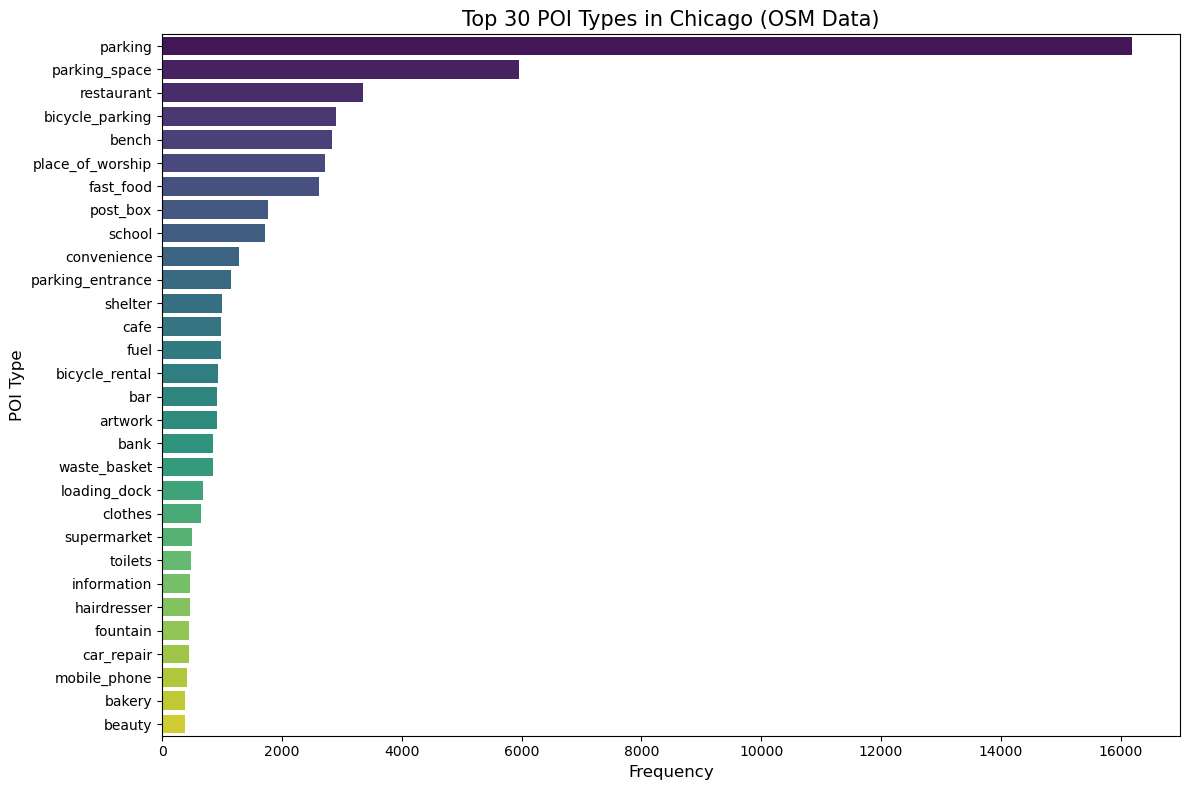

In [64]:
poi_counts = pois['poi_type'].value_counts().head(30) # Top 30 for clarity
# Create Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=poi_counts.values, y=poi_counts.index, palette='viridis', hue = poi_counts.index, legend=False)
plt.title('Top 30 POI Types in Chicago (OSM Data)', fontsize=15)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('POI Type', fontsize=12)
plt.tight_layout()
plt.show()

In [65]:
unique_poi_types = pois['poi_type'].unique()

print(f"Total unique poi types: {len(unique_poi_types)}")
print(unique_poi_types)

Total unique poi types: 364
['ferry_terminal' 'parking' 'picnic_site' 'parking_entrance' 'post_box'
 'bicycle' 'loading_dock' 'theatre' 'information' 'convenience'
 'car_repair' 'bicycle_parking' 'place_of_worship' 'fast_food' 'furniture'
 'books' 'post_office' 'dry_cleaning' 'drinking_water' 'toilets'
 'supermarket' 'restaurant' 'pharmacy' 'stationery' 'fuel' 'clothes'
 'cafe' 'cinema' 'clock' 'pub' 'vacant' 'school' 'university' 'grave_yard'
 'kindergarten' 'dojo' 'driving_school' 'childcare' 'college'
 'music_school' 'artwork' 'language_school' 'social_facility'
 'prep_school' 'public_bath' 'social_centre' 'art' 'arts_centre'
 'courthouse' 'fire_station' 'library' 'police' 'townhall' 'bar'
 'department_store' 'bank' 'atm' 'pet' 'hotel' 'ice_cream' 'hairdresser'
 'mobile_phone' 'car_wash' 'veterinary' 'beauty' 'costume' 'doctors'
 'electronics' 'alcohol' 'houseware' 'military_surplus' 'bakery'
 'fountain' 'chemist' 'dentist' 'bench' 'waste_basket' 'general'
 'car_rental' 'pastry' 'ho

## Drop unneeded POIS
We decided to only use high-impact POIS and drop amenities that are infrastructure-related (unlikely to be a destination), hyper-local objects (clocks, benches), or private residential/specific use cases that don't generate high-frequency ride-hailing traffic.

In [73]:
values_to_drop = [
    'post_box', 'drinking_water', 'toilets', 'clock', 'fountain', 'bench', 
    'waste_basket', 'recycling', 'ticket_validator', 'shower', 'vending_machine', 
    'locker', 'bicycle_repair_station', 'public_bookcase', 'library_dropoff', 
    'waste_disposal', 'bbq', 'payment_terminal', 'photo_booth', 'grit_bin', 
    'letter_box', 'binoculars', 'waste_transfer_station', 'compressed_air', 
    'vacuum_cleaner', 'lounger', 'weighbridge', 'give_box', 'watering_place', 
    'Concrete Paving', 'bird_bath', 'dog_toilet', 'smoking_area', 'hitching_post', 
    'printer', 'trolley_bay', 'security_booth', 'stage', 'device_charging_station', 
    'parcel_locker', 'power_tools', 'window_blind', 'printer_ink', 'outpost', 
    'groundskeeping', 'bicycle_parking', 'motorcycle_parking', 'bicycle_wash', 
    'loading_dock', 'parking_entrance', 'parking_exit', 'parking_space', 
    'bicycle', 'trail_riding_station', 'grave_yard', 'dojo', 'prep_school', 
    'public_bath', 'language_school', 'animal_shelter', 'animal_boarding', 
    'animal_breeding', 'animal_training', 'tool_library', 'lost_property_office', 
    'dressing_room', 'mortuary', 'monastery', 'car_pound', 'boat_storage', 
    'retirement_home', 'nursing_home', 'crematorium', 'prison', 'fraternity', 
    'camp_pitch', 'vacant', 'vacant;yes', 'yes', 'military_surplus'
]

# Filter the POIs DataFrame
pois_cleaned = pois[~pois['poi_type'].isin(values_to_drop)]
pois = pois_cleaned[['id', 'poi_type', 'name', 'geometry']].dropna(subset=["geometry"])

# Get the H3 index for each POI
pois['h3_index'] = pois.apply(get_h3_index, axis=1)
pois.head()

,id,poi_type,name,geometry,h3_index
0,20217109,ferry_terminal,Shoreline Sightseeing,POINT (-87.62252 41.88914),882664c1e3fffff
1,20217442,ferry_terminal,Union Station/Willis Tower,POINT (-87.63774 41.87906),882664c1adfffff
3,262376566,picnic_site,None,POINT (-87.92891 42.03411),8827593717fffff
11,271275603,theatre,Storefront Theater,POINT (-87.62551 41.88481),882664c1a9fffff
12,282360641,information,Oak Park Visitors Center,POINT (-87.801 41.8888),882664c825fffff


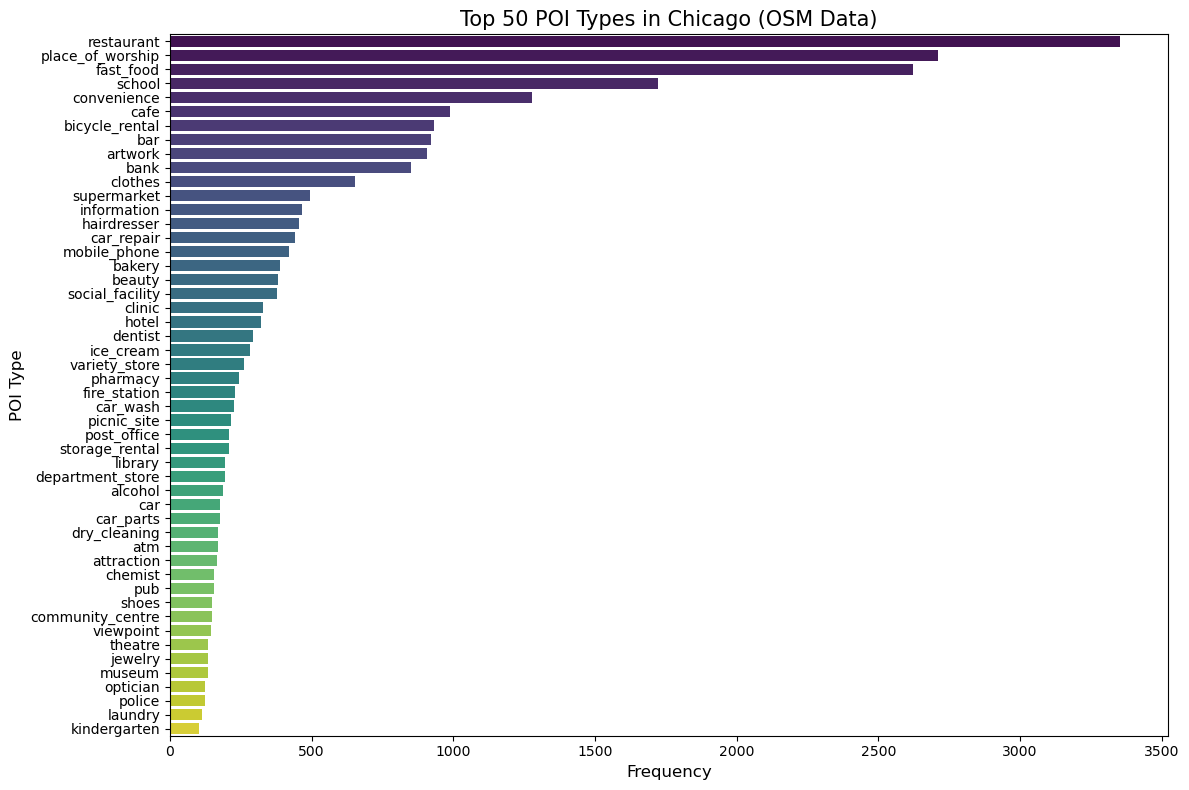

In [71]:
poi_counts = pois['poi_type'].value_counts().head(50) # Top 50 for clarity
# Create Plot
plt.figure(figsize=(12, 8))
sns.barplot(x=poi_counts.values, y=poi_counts.index, palette='viridis', hue = poi_counts.index, legend=False)
plt.title('Top 50 POI Types in Chicago (OSM Data)', fontsize=15)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('POI Type', fontsize=12)
plt.tight_layout()
plt.show()